# HW02-1：股票收益与组合风险分析

- 姓名：王振宇
- [教师作业页面](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- GitHub 仓库：https://github.com/CLUD-88/FinEco-hw；[HW02-1 目录](https://github.com/CLUD-88/FinEco-hw/tree/main/hw02-1)；[HW02-2 目录](https://github.com/CLUD-88/FinEco-hw/tree/main/hw02-2)
- 数据来源：AKShare 1.18.97，经腾讯证券日度行情和东方财富历史估值接口获取；本地下载日期：2026-09-23；样本期间：2021-01-01 至 2026-09-16，另取 2020-12-31 计算首日收益率。
- AI 使用声明：使用 OpenAI Codex 辅助数据获取、代码编写与初稿核验；具体使用记录见文末。本人提交前仍需逐项复核样本选择、计算结果、图形与解释。

本题选取 10 只横跨 8 个行业的 A 股，用后复权价格计算日简单收益率，比较股票风险收益特征以及每日再平衡的等权和滞后一日总市值加权组合。所有分析以本地保存的数据快照为准，避免以后接口更新改变结果。

## 1. 选股、来源与数据读取

**分析思路。** 选取在 2021 年以前上市、横跨多行业且样本覆盖完整的股票；银行和白酒各保留两家以观察同行业相关性。行业来自 CSMAR 上市公司基本信息年度表的 2025-12-31 记录，全部使用同一分类来源与日期。选股理由以行业和商业模式代表性为主，不以事后涨幅筛选。

- 不复权日线、后复权日线：`ak.stock_zh_a_hist_tx(symbol, start_date='20201201', end_date='20260916', adjust=''/'hfq')`；价格单位元/股。
- 历史总市值：`ak.stock_value_em(symbol)` 的 `总市值` 字段，单位元；与行情按代码和日期一对一合并。价格源为腾讯，市值源为东方财富，二者均通过 AKShare 取得。
- 成交额 `amount` 单位元。下载接口的 `volume` 字段在本次样本存在沪深市场单位不一致：沪市约为股、深市约为手；下文通过“成交额/(成交量×收盘价)”检查，不直接混合原始 `volume`。成交额满足本题的成交量**或**成交额要求。
- 后复权价格只用于收益率，不当作实际成交价；历史总市值直接取数据库字段，不用后复权价乘股本重算。

[AKShare 股票数据接口与复权说明](https://akshare.akfamily.xyz/data/stock/stock.html)。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
DATA = Path('data')
selection = pd.read_csv(DATA / 'selection.csv', dtype={'代码': str})
codes = selection['代码'].tolist()
frames = [pd.read_csv(DATA / f'{code}.csv', dtype={'code': str}, parse_dates=['date']) for code in codes]
daily = pd.concat(frames, ignore_index=True)
display(selection[['代码', '简称', '行业', '上市日期', '选股理由', '分类日期']])
print('股票数:', len(codes), '行业数:', selection['行业'].nunique())
print('主键重复数:', daily.duplicated(['code', 'date']).sum())

,代码,简称,行业,上市日期,选股理由,分类日期
0,000001,平安银行,银行,1991-04-03,银行业代表,2025-12-31
1,600036,招商银行,银行,2002-04-09,股份制银行代表,2025-12-31
2,600519,贵州茅台,酒、饮料和精制茶制造业,2001-08-27,白酒龙头,2025-12-31
3,000858,五粮液,酒、饮料和精制茶制造业,1998-04-27,白酒行业对照,2025-12-31
4,000333,美的集团,电气机械和器材制造业,2013-09-18,家电制造代表,2025-12-31
5,002415,海康威视,计算机、通信和其他电子设备制造业,2010-05-28,电子设备代表,2025-12-31
6,600276,恒瑞医药,医药制造业,2000-10-18,医药制造代表,2025-12-31
7,600011,华能国际,电力、热力生产和供应业,1994-10-05,公用事业代表,2025-12-31
8,601888,中国中免,商务服务业,2009-10-15,消费服务代表,2025-12-31
9,600104,上汽集团,汽车制造业,1997-11-25,汽车制造代表,2025-12-31


股票数: 10 行业数: 8
主键重复数: 0


**结果解读。** 10 只股票覆盖银行、酒饮料、家电制造、电子设备制造、医药制造、电力、商务服务和汽车制造等 **8 个行业**，全部在 2021 年前上市。银行与白酒各有两只，便于在相关性矩阵中观察同行业联动。样本设计具有代表性，但属于事后选定的固定名单，因此不能把回测表现解释为当时可预知的选股收益。

- 行业分类统一使用 CSMAR 2025 年末年度表，可能与历史时点行业分类不同；本题只用它描述选股结构，不将它用于逐年行业追踪。
- 下载快照固定了分析版本；换日期重新请求可能得到不同的复权或市值数据。

## 2. 日期、缺失、单位与收益率检查

**分析思路。** 用所有样本股票的交易日并集作日历，对每只股票显式补齐缺失日期。用后复权收盘价的相邻交易日比值计算简单收益率；不前填停牌日价格，避免把跨日变化算成一个正常单日收益。组合仅在 10 只股票收益与上一交易日总市值同时齐备的日期计算。

- 检查主键唯一、覆盖起止、有效观测数、缺失交易日和市值。
- 通过成交额与价格、成交量的数量级核对原始交易量单位；主分析使用成交额（元）。
- 报告日收益率绝对值较大的日期，不机械缩尾。

In [2]:
daily = daily.sort_values(['code', 'date'])
calendar = pd.DatetimeIndex(sorted(daily.date.unique()), name='date')
raw_close = daily.pivot(index='date', columns='code', values='close').reindex(calendar)[codes]
adjusted_close = daily.pivot(index='date', columns='code', values='close_hfq').reindex(calendar)[codes]
market_cap = daily.pivot(index='date', columns='code', values='market_cap_yuan').reindex(calendar)[codes]
amount = daily.pivot(index='date', columns='code', values='amount').reindex(calendar)[codes]
start, end = pd.Timestamp('2021-01-01'), pd.Timestamp('2026-09-16')
sample_dates = calendar[(calendar >= start) & (calendar <= end)]
returns = adjusted_close.pct_change(fill_method=None).reindex(sample_dates)
prior_day = calendar[calendar < start].max()
coverage = pd.DataFrame({
    '首日': [str(raw_close[c].loc[sample_dates].dropna().index.min().date()) for c in codes],
    '末日': [str(raw_close[c].loc[sample_dates].dropna().index.max().date()) for c in codes],
    '价格日数': raw_close.loc[sample_dates].count().to_numpy(),
    '有效收益日数': returns.count().to_numpy(),
    '缺失交易日': raw_close.loc[sample_dates].isna().sum().to_numpy(),
    '缺失总市值日': market_cap.loc[sample_dates].isna().sum().to_numpy(),
}, index=codes)
display(coverage)
print('首日收益率所用前一交易日:', prior_day.date())
print('重复 code-date:', daily.duplicated(['code', 'date']).sum())
unit_check = daily.groupby('code').apply(
    lambda x: (x['amount'] / (x['close'] * x['volume'])).median(), include_groups=False
).rename('成交额/(收盘价×原始成交量)')
display(unit_check.to_frame().round(2))
extreme = returns.stack().rename('日收益率').reset_index().rename(columns={'level_1': '代码'})
extreme['绝对值'] = extreme['日收益率'].abs()
display(extreme.nlargest(10, '绝对值'))

,首日,末日,价格日数,有效收益日数,缺失交易日,缺失总市值日
000001,2021-01-04,2026-09-16,1384,1384,0,0
600036,2021-01-04,2026-09-16,1384,1384,0,0
600519,2021-01-04,2026-09-16,1384,1384,0,0
000858,2021-01-04,2026-09-16,1384,1384,0,0
000333,2021-01-04,2026-09-16,1384,1384,0,0
002415,2021-01-04,2026-09-16,1384,1384,0,0
600276,2021-01-04,2026-09-16,1384,1384,0,0
600011,2021-01-04,2026-09-16,1384,1384,0,0
601888,2021-01-04,2026-09-16,1384,1384,0,0
600104,2021-01-04,2026-09-16,1384,1384,0,0


首日收益率所用前一交易日: 2020-12-31
重复 code-date: 0


,成交额/(收盘价×原始成交量)
code,
000001,100.00
000333,99.99
000858,100.04
002415,1.00
600011,1.00
600036,1.00
600104,1.00
600276,1.00
600519,1.00


,date,code,日收益率,绝对值
658,2021-04-13,601888,-0.098917,0.098917
1546,2021-08-20,600276,-0.098574,0.098574
1988,2021-11-01,601888,-0.098458,0.098458
3156,2022-04-25,600276,-0.097814,0.097814
11056,2025-07-28,600276,0.097480,0.097480
4296,2022-10-14,600276,0.097351,0.097351
3068,2022-04-12,601888,0.097347,0.097347
4418,2022-11-01,601888,0.096565,0.096565
4946,2023-01-16,600276,0.096097,0.096097
15,2021-01-05,002415,0.094368,0.094368


**结果解读。** 最终 10 只股票在 2021-01-04 至 2026-09-16 的 **1,384 个共同交易日**均有价格、后复权价格和历史总市值；首日收益率使用 2020-12-31。检查中长江电力有 11 个未交易日，因而改用同属电力行业且覆盖完整的华能国际。最终组合不需对停牌收益做零填充，也没有跨日收益混入。

成交额除以“不复权收盘价×原始成交量”的中位数，深市四只股票约为 100，沪市股票约为 1，表明本次腾讯接口的原始 `volume` **实际单位并不一致**。因此主分析只使用单位稳定的 `amount`（元），不直接聚合原始成交量。样本最大单日绝对后复权收益约 9.9%，未发现明显超出普通 A 股日涨跌幅量级的值；极端日期仍保留，并在波动图中可见。

- 10 只股票的价格、总市值与收益率有效日数均为 1,384，主键无重复。
- 后复权收益体现价格调整后的公司行为；它不是投资者实际按后复权价交易的价格记录。

## 3. 价格、累计表现、日收益与滚动波动

**分析思路。** 原始收盘价分面绘图，避免价位差异掩盖低价股票；累计净值从 1 起步，使用调整后日收益连乘。20 个交易日滚动波动率以窗口内收益率样本标准差乘以 √252 计算，不足完整窗口保持空值。

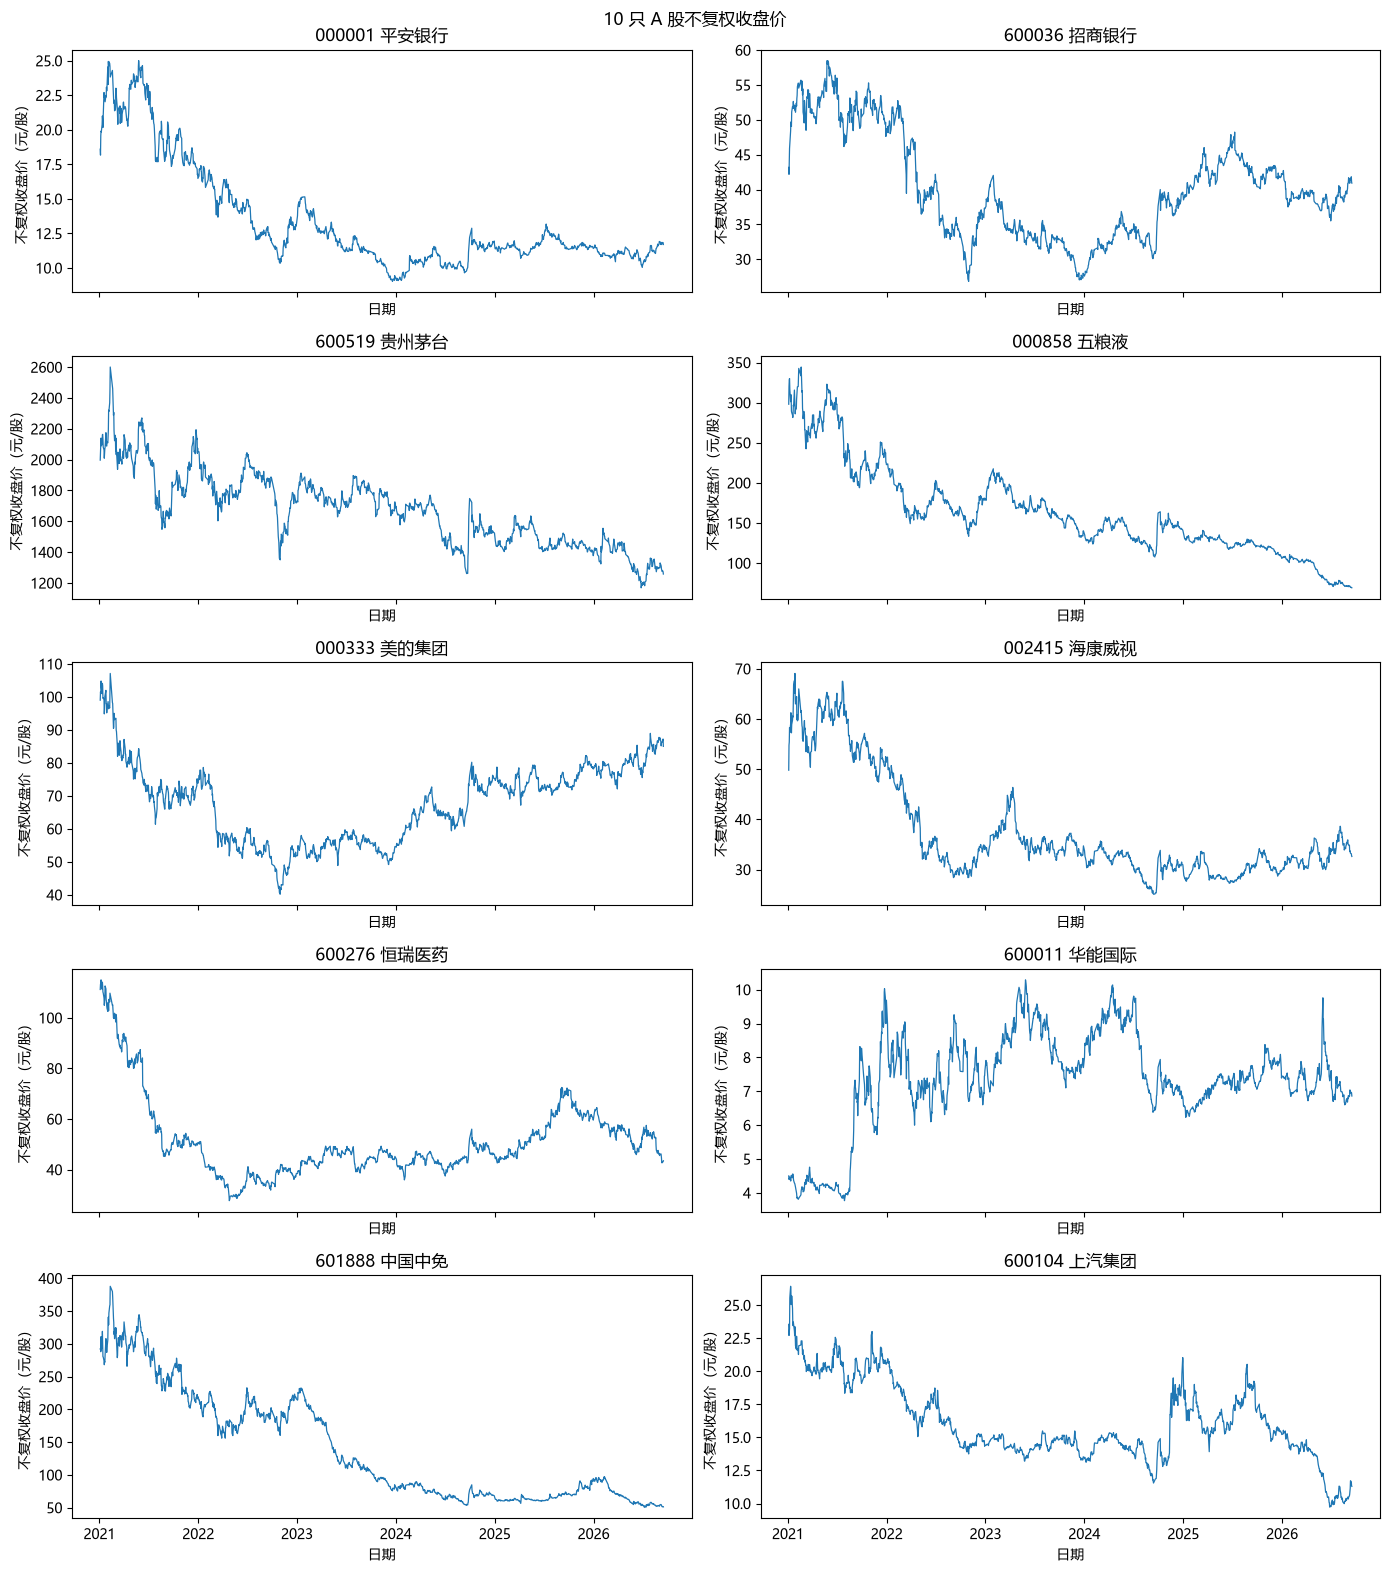

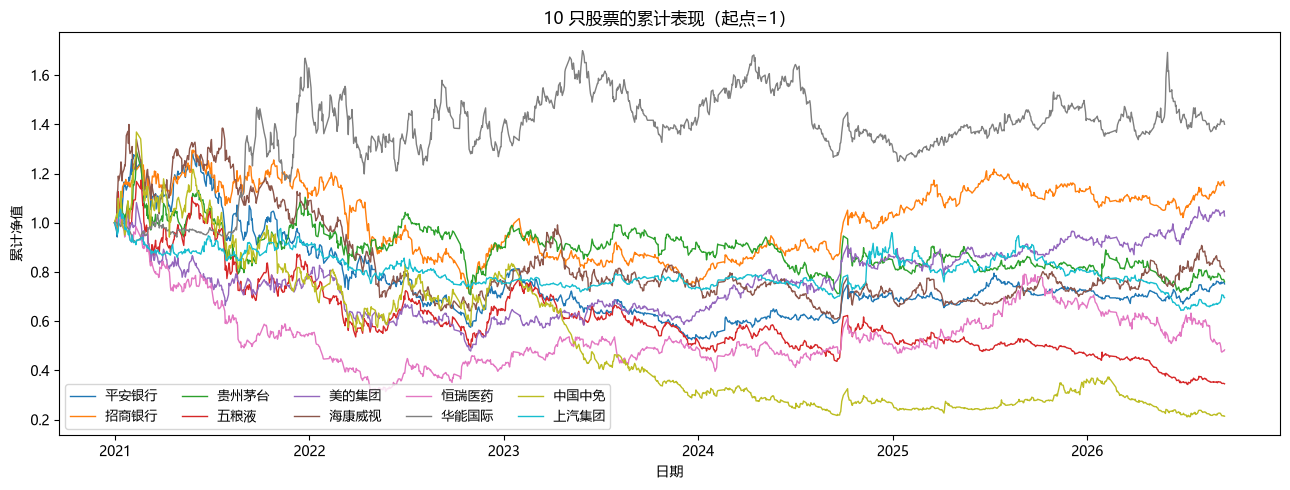

In [3]:
name_map = dict(zip(selection['代码'], selection['简称']))
fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
for ax, code in zip(axes.flat, codes):
    ax.plot(sample_dates, raw_close.loc[sample_dates, code], linewidth=.9)
    ax.set(title=f'{code} {name_map[code]}', ylabel='不复权收盘价（元/股）')
    ax.set_xlabel('日期')
fig.suptitle('10 只 A 股不复权收盘价')
fig.tight_layout()
plt.show()

cumulative = (1 + returns).cumprod()
cumulative = pd.concat([pd.DataFrame(1.0, index=[prior_day], columns=codes), cumulative])
fig, ax = plt.subplots(figsize=(13, 5))
for code in codes:
    ax.plot(cumulative.index, cumulative[code], label=name_map[code], linewidth=1)
ax.set(title='10 只股票的累计表现（起点=1）', xlabel='日期', ylabel='累计净值')
ax.legend(ncol=5, fontsize=9)
fig.tight_layout()
plt.show()

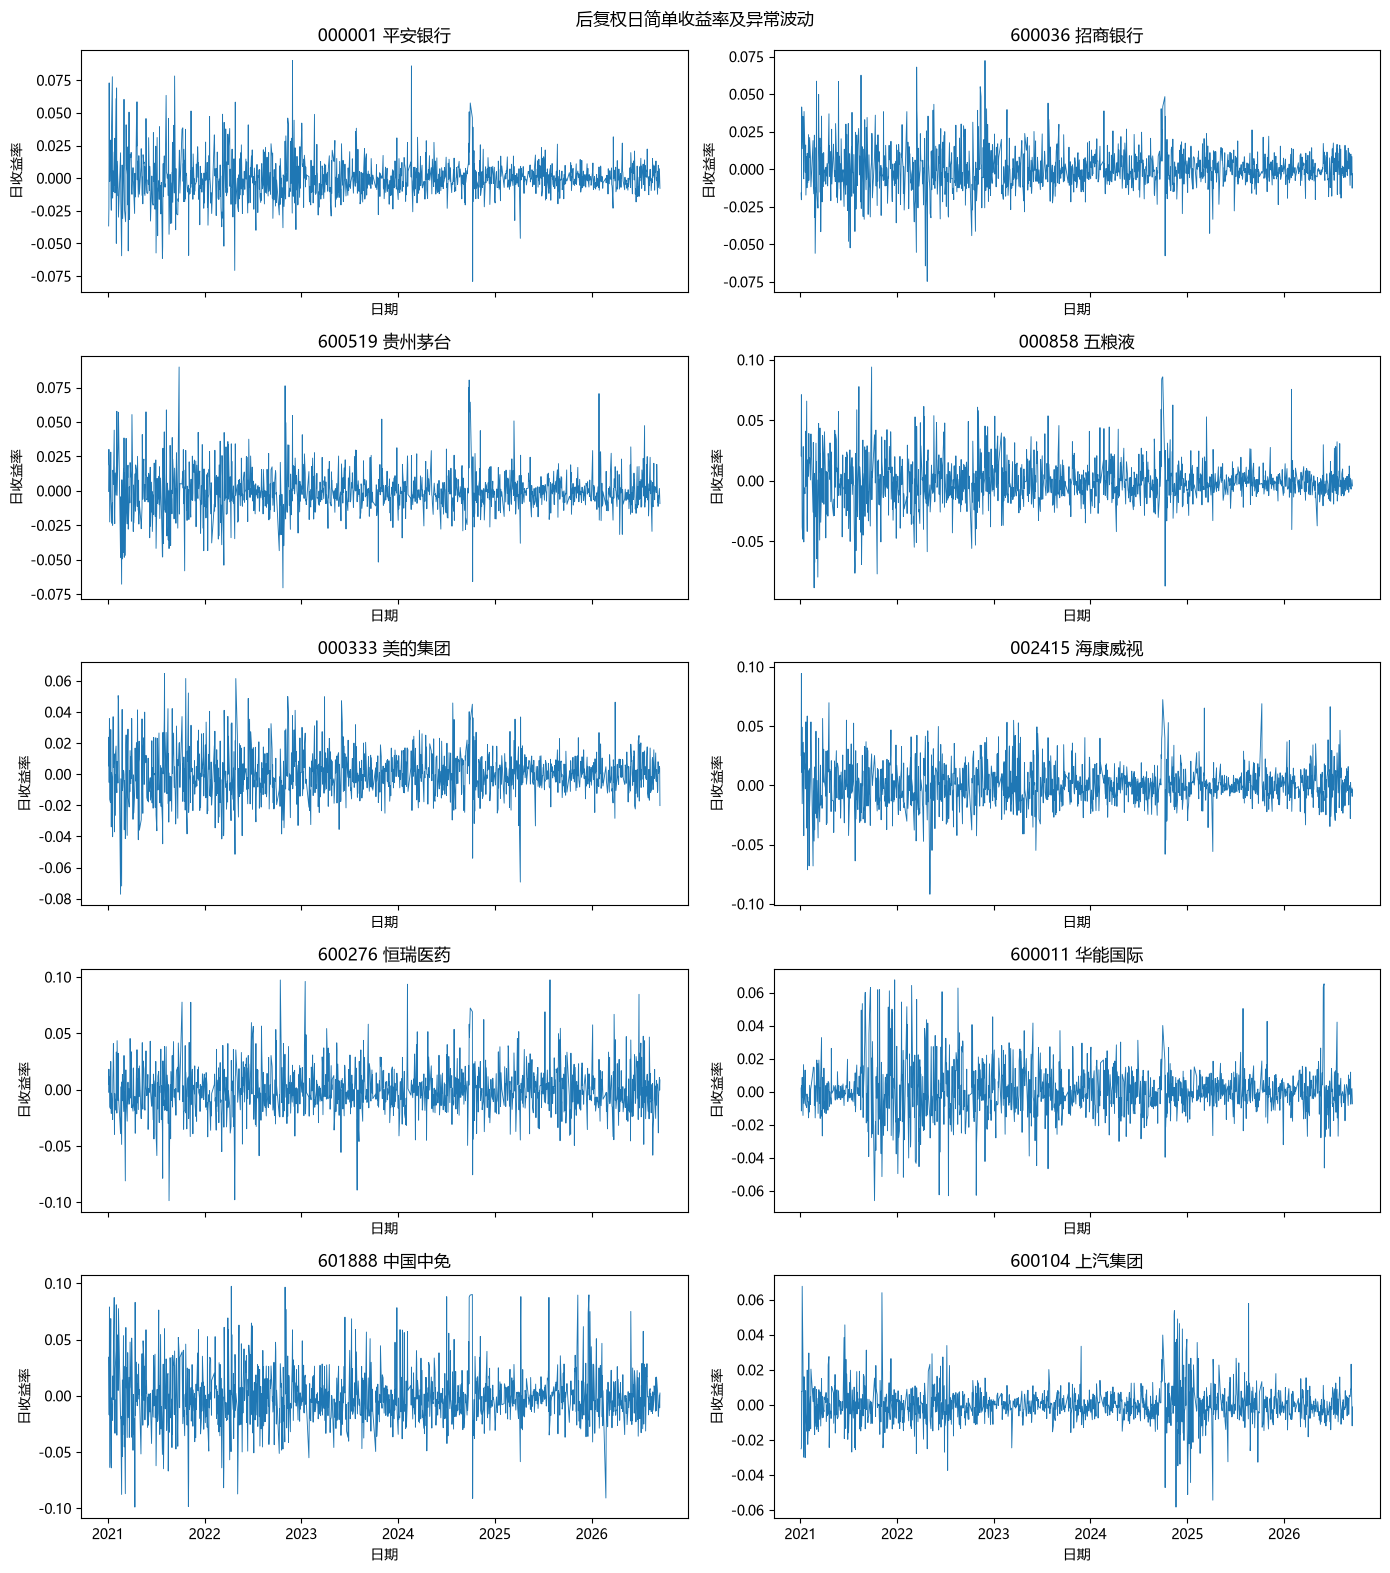

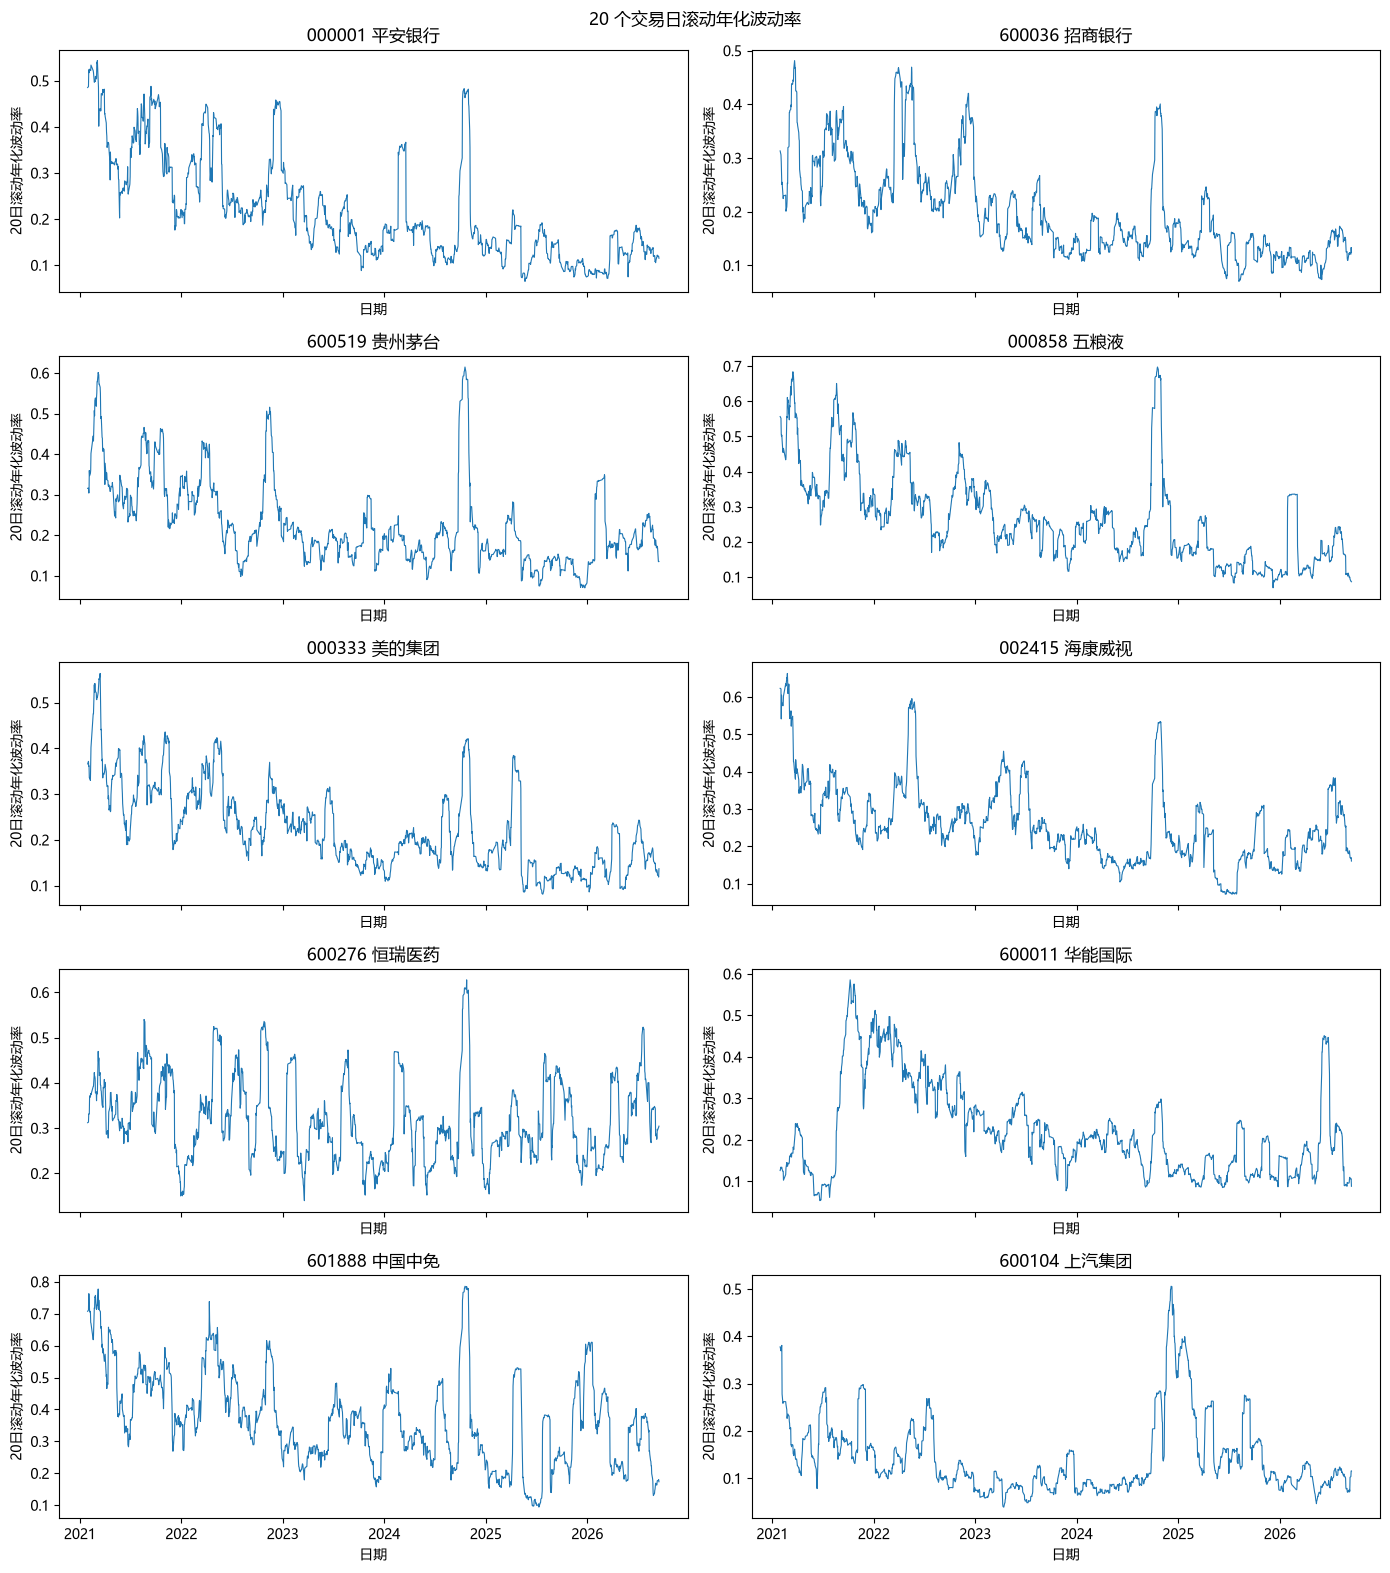

前 19 日滚动波动率均为空: True


In [4]:
rolling_vol = returns.rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
for ax, code in zip(axes.flat, codes):
    ax.plot(returns.index, returns[code], linewidth=.65)
    ax.set(title=f'{code} {name_map[code]}', ylabel='日收益率', xlabel='日期')
fig.suptitle('后复权日简单收益率及异常波动')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
for ax, code in zip(axes.flat, codes):
    ax.plot(rolling_vol.index, rolling_vol[code], linewidth=.8)
    ax.set(title=f'{code} {name_map[code]}', ylabel='20日滚动年化波动率', xlabel='日期')
fig.suptitle('20 个交易日滚动年化波动率')
fig.tight_layout()
plt.show()
print('前 19 日滚动波动率均为空:', rolling_vol.iloc[:19].isna().all().all())

**结果解读。** 不复权价格图展示实际报价水平，累计净值图才用于跨股票比较。到样本终点，华能国际的累计收益约 **+40.1%**，中国中免约 **−78.6%**；同一时期股票差异很大。中国中免年化日波动率约 **39.6%**，高于上汽集团的约 **16.7%**，而高波动并未带来较高实现收益。这只是样本期内的风险收益关系，不能推出未来规律。

- 滚动波动率随时间变化，固定年化波动率不能概括每一阶段风险。
- 单日异常波动可能来自市场信息、价格限制或公司行为；仅凭日线不能确定具体原因，不能把所有尖峰都当成错误数据。

## 4. 描述统计与相关性

**分析思路。** 对每只股票报告有效收益数、均值、样本标准差、最小值、中位数、最大值、偏度和超额峰度。Pearson 相关系数按同一交易日对齐；同时检查每对股票的有效共同日数。

,简称,有效观测数,日均收益,日标准差,最小值,中位数,最大值,偏度,超额峰度,年化波动率
code,,,,,,,,,,
000001,平安银行,1384,-0.0001,0.0156,-0.0790,-0.0007,0.0900,0.6799,5.2795,0.2476
600036,招商银行,1384,0.0002,0.0140,-0.0747,-0.0005,0.0723,0.2505,3.7147,0.2215
600519,贵州茅台,1384,-0.0001,0.0157,-0.0704,-0.0009,0.0899,0.5030,4.2700,0.2492
000858,五粮液,1384,-0.0006,0.0188,-0.0884,-0.0018,0.0940,0.3218,3.7907,0.2989
000333,美的集团,1384,0.0001,0.0152,-0.0772,-0.0001,0.0648,0.0917,2.3241,0.2410
002415,海康威视,1384,-0.0000,0.0178,-0.0919,-0.0003,0.0944,0.2104,2.8342,0.2830
600276,恒瑞医药,1384,-0.0003,0.0209,-0.0986,-0.0015,0.0975,0.3610,2.8973,0.3324
600011,华能国际,1384,0.0004,0.0156,-0.0660,-0.0007,0.0677,0.5091,3.4015,0.2473
601888,中国中免,1384,-0.0008,0.0249,-0.0989,-0.0027,0.0973,0.5359,2.3742,0.3960


code,000001,600036,600519,000858,000333,002415,600276,600011,601888,600104
code,,,,,,,,,,
000001,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
600036,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
600519,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
000858,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
000333,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
002415,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
600276,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
600011,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384
601888,1384,1384,1384,1384,1384,1384,1384,1384,1384,1384


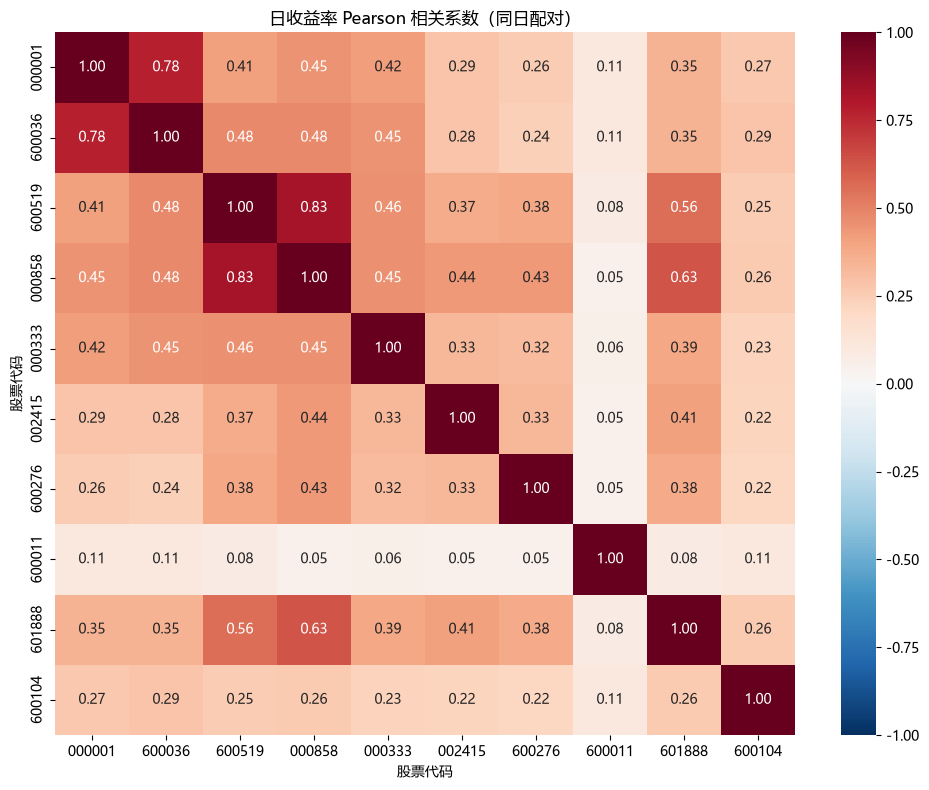

In [5]:
desc = pd.DataFrame({
    '有效观测数': returns.count(),
    '日均收益': returns.mean(),
    '日标准差': returns.std(ddof=1),
    '最小值': returns.min(),
    '中位数': returns.median(),
    '最大值': returns.max(),
    '偏度': returns.skew(),
    '超额峰度': returns.kurt(),
    '年化波动率': returns.std(ddof=1) * np.sqrt(252),
})
desc.insert(0, '简称', [name_map[c] for c in desc.index])
display(desc.round(4))
corr = returns.corr(method='pearson')
pair_n = returns.notna().astype(int).T @ returns.notna().astype(int)
display(pair_n)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='RdBu_r', ax=ax)
ax.set(title='日收益率 Pearson 相关系数（同日配对）', xlabel='股票代码', ylabel='股票代码')
fig.tight_layout()
plt.show()

**结果解读。** 两只白酒股（贵州茅台与五粮液）的日收益相关系数约 **0.829**，两只银行股（平安银行与招商银行）约 **0.777**，均高于许多跨行业组合，符合共同产业或板块冲击的可能性。但相关性不证明共同原因，也可能受到市场整体波动影响。所有股票对都用同一 **1,384 个交易日**计算，因而矩阵比较不受不同配对样本量干扰。

- 中国中免波动最高，上汽集团波动最低；均值和收益率分布偏态、厚尾需要与极端日检查一起阅读。
- 同行业两只股票相关性高，说明仅增加同行业股票未必能得到充分分散。

## 5. 等权与滞后总市值加权组合

**分析思路。** 每日按目标权重计算组合收益并假设当日再平衡、不计交易成本。等权每只股票 0.1；市值组合用**上一交易日收盘总市值**确定当日权重。两者在相同、连续的 1,384 个交易日评价。几何年化收益率按最终净值的 `252/T` 次方减一；年化波动率用组合日收益样本标准差；最大回撤报告非负数。

- 核验每日权重和为 1、无缺失、每只股票的上一交易日市值与当日收益日期对齐。
- 市值使用“总市值”，绝不改用流通市值或后复权股价估算。

,有效日数,累计收益率,几何年化收益率,年化波动率,最大回撤
等权,1384.0,-0.2372,-0.0481,0.1714,0.4155
市值加权,1384.0,-0.2848,-0.0592,0.1944,0.4857


组合日期: 2021-01-04 至 2026-09-16
市值权重最大日内和误差: 4.440892098500626e-16
市值权重最大单股占比: 0.4317


,末日权重
code,
000001,0.0485
600036,0.2194
600519,0.3367
000858,0.0573
000333,0.1408
002415,0.0636
600276,0.0606
600011,0.0231
601888,0.0224


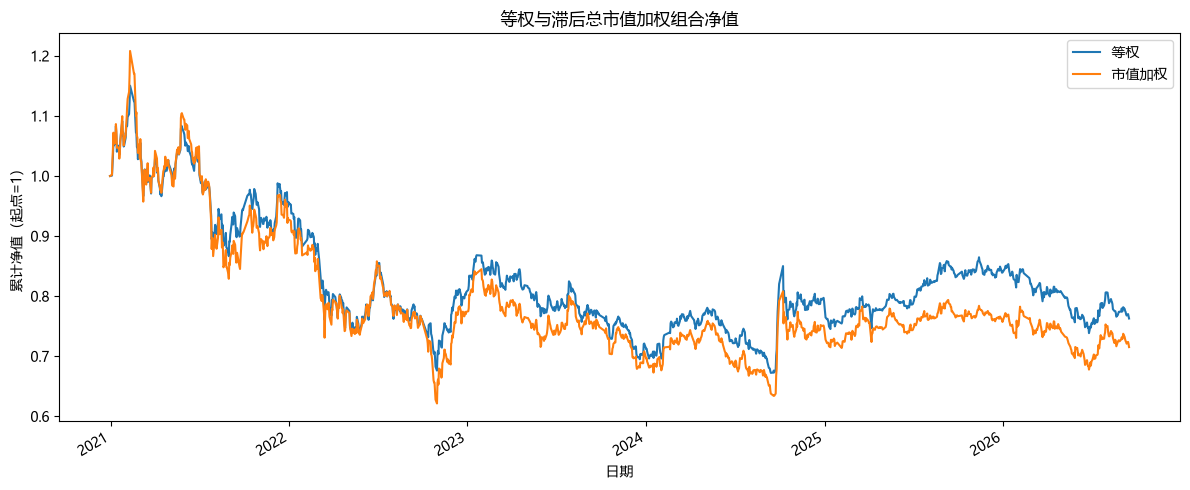

In [6]:
prior_cap = market_cap.shift(1).reindex(sample_dates)
complete = returns.notna().all(axis=1) & prior_cap.notna().all(axis=1)
assert complete.all(), '组合评价期出现缺失日，须重新确定连续区间'
weights = prior_cap.div(prior_cap.sum(axis=1), axis=0)
assert np.allclose(weights.sum(axis=1), 1)
portfolio = pd.DataFrame(index=sample_dates)
portfolio['等权'] = (returns * .1).sum(axis=1)
portfolio['市值加权'] = (weights * returns).sum(axis=1)
nav = (1 + portfolio).cumprod()
nav = pd.concat([pd.DataFrame(1.0, index=[prior_day], columns=nav.columns), nav])

def evaluate(series):
    wealth = (1 + series).cumprod()
    drawdown = 1 - wealth / wealth.cummax().clip(lower=1)
    return pd.Series({
        '有效日数': len(series),
        '累计收益率': wealth.iloc[-1] - 1,
        '几何年化收益率': wealth.iloc[-1] ** (252 / len(series)) - 1,
        '年化波动率': series.std(ddof=1) * np.sqrt(252),
        '最大回撤': drawdown.max(),
    })

summary = portfolio.apply(evaluate).T
display(summary.round(4))
print('组合日期:', portfolio.index.min().date(), '至', portfolio.index.max().date())
print('市值权重最大日内和误差:', float((weights.sum(axis=1) - 1).abs().max()))
print('市值权重最大单股占比:', round(float(weights.max(axis=1).max()), 4))
display(weights.iloc[-1].rename('末日权重').to_frame().round(4))
fig, ax = plt.subplots(figsize=(12, 5))
nav.plot(ax=ax)
ax.set(title='等权与滞后总市值加权组合净值', xlabel='日期', ylabel='累计净值（起点=1）')
fig.tight_layout()
plt.show()

**结果解读。** 等权组合累计收益约 **−23.7%**，几何年化收益约 **−4.8%**，年化波动率约 **17.1%**，最大回撤约 **41.6%**；市值加权组合分别约 **−28.5%、−5.9%、19.4%、48.6%**。两者均使用相同的 1,384 个连续交易日。市值组合表现较差且波动、回撤较高，说明这组样本和期间的市值权重没有带来更好的分散效果。

市值权重单股最高约 **43.2%**；末日贵州茅台约占 **33.7%**、招商银行约占 **21.9%**。等权对十只股票平均配置，市值组合则明显集中在大市值股票。组合波动率由组合收益序列计算，**不是**个股波动率的加权平均。此回测忽略交易成本、冲击、税费和可交易性，且选股名单事后固定，不能视为历史真实可实施策略或未来收益预测。

- 该样本中等权在收益、波动和回撤三项上均优于市值加权，但换股票或期间后不一定如此。
- 两种组合均有显著回撤，分散投资降低个股特有风险，却无法消除市场共同风险。

## 6. 总体结论

10 只 A 股在 2021 年初至 2026-09-16 的表现差异很大；高波动股票不必然取得高收益。同行业股票相关性较高，提示组合需要跨行业分散。在这组固定样本中，等权组合比前一日总市值加权组合有更高的累计与年化收益，同时年化波动和最大回撤更低；市值组合权重集中是重要的描述性解释。数据处理的关键判断是使用后复权价格计算收益、直接使用历史总市值、核对沪深原始成交量单位并改用成交额、确保组合全期日期连续。结论只针对本次事后选定样本及无交易成本的教学设定。

## AI 使用记录

使用 OpenAI Codex 辅助检索 AKShare 文档、编写下载与分析代码、检查接口及数据质量、撰写初版解读。给 AI 的任务说明（根据实际对话整理，非逐字引述）：“请按 HW02-1 的要求使用 AKShare 获取 A 股历史行情与总市值，计算股票收益和两类组合，并核对日期、单位、缺失值及异常收益。”初稿核验发现腾讯行情的原始成交量在沪深股票间存在单位差异，因此主分析改用成交额；还检查了 10 只股票的共同交易日、总市值覆盖和 Notebook 执行错误。提交前已本人核验上述判断与结果。